In [ ]:
import joblib
import pandas as pd
from tabulate import tabulate

In [ ]:
# load trained model
model = joblib.load("/content/drive/MyDrive/RKdemy/fertilizer_model_final_V2.pkl")

soil_encoder = joblib.load("/content/drive/MyDrive/RKdemy/soil_encoder.pkl")
crop_encoder = joblib.load("/content/drive/MyDrive/RKdemy/crop_encoder.pkl")
stage_encoder = joblib.load("/content/drive/MyDrive/RKdemy/stage_encoder.pkl")
fert_encoder = joblib.load("/content/drive/MyDrive/RKdemy/fert_encoder.pkl")

thresholds = joblib.load("/content/drive/MyDrive/RKdemy/nutrient_thresholds.pkl")

feature_columns = joblib.load("/content/drive/MyDrive/RKdemy/feature_columns.pkl")

**Test Inputs For Nitrogen Deficiency (Usually → Urea)**

In [ ]:
Soil Type: Silt
Soil pH: 6.4
Soil Moisture: 32

Nitrogen Level: 35
Phosphorus Level: 55
Potassium Level: 60

Temperature: 27
Humidity: 65
Rainfall: 1400

Crop Type: Maize
Crop Growth Stage: Vegetative

**Test Inputs For Phosphorus Deficiency (Usually → DAP)**

In [ ]:
Soil Type: Sandy
Soil pH: 6.5
Soil Moisture: 30

Nitrogen Level: 110
Phosphorus Level: 15
Potassium Level: 70

Temperature: 26
Humidity: 60
Rainfall: 1500

Crop Type: Wheat
Crop Growth Stage: Vegetative

**Test Inputs For Potassium Deficiency (Usually → MOP)**

In [ ]:
Soil Type: Loamy
Soil pH: 6.7
Soil Moisture: 40

Nitrogen Level: 100
Phosphorus Level: 50
Potassium Level: 12

Temperature: 25
Humidity: 70
Rainfall: 1600

Crop Type: Rice
Crop Growth Stage: Vegetative

**Test Inputs For Balanced Soil → Very Low Quantity / Possibly NPK**

In [ ]:
Soil Type: Clay
Soil pH: 6.6
Soil Moisture: 45

Nitrogen Level: 110
Phosphorus Level: 50
Potassium Level: 60

Temperature: 26
Humidity: 68
Rainfall: 1500

Crop Type: Tomato
Crop Growth Stage: Vegetative

**Agronomy Reference**

[Crop Nutrient Requirement](https://www.agritech.tnau.ac.in/expert_system/paddy/riceecosystem.html)


[Crop Production Guide](https://agritech.tnau.ac.in/pdf/AGRICULTURE.pdf)

[Rating Chart for Soil](https://agritech.tnau.ac.in/agriculture/agri_soil_soilratingchart.html)

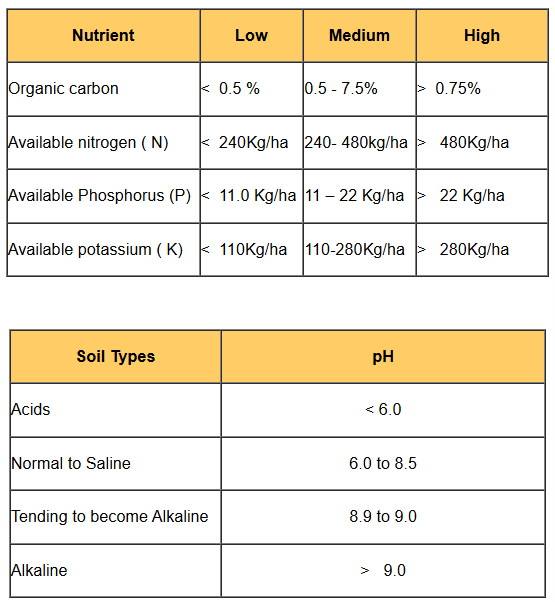

**Soil pH Status Logic**

In [ ]:
def soil_ph_status(ph):
    if ph < 6.0:
        return "Acidic Soil"
    elif 6.0 <= ph <= 8.5:
        return "Normal / Optimal Soil"
    elif 8.5 < ph <= 9.0:
        return "Tending to Alkaline"
    else:
        return "Alkaline Soil"

**Soil nutrient status logic**

In [ ]:
def nutrient_status(value, low, high):
    if value < low:
        return "Low"
    elif value <= high:
        return "Medium"
    else:
        return "High"

**Fertilizer Dosage Reference Table**

In [ ]:
fertilizer_dosage = {
    "Urea": "100–200 kg/ha",
    "DAP": "80–150 kg/ha",
    "MOP": "60–120 kg/ha",
    "SSP": "150–250 kg/ha",
    "NPK": "100–200 kg/ha",
    "Compost": "2–5 tons/ha",
    "Zinc Sulphate": "20–25 kg/ha"
}

**Take User Input**

In [ ]:
print("\nEnter Soil and Crop Parameters\n")

# Take inputs
soil_type = input("Soil Type (Sandy/Clay/Silt/Loamy): ")
soil_ph = float(input("Soil pH: "))
soil_moisture = float(input("Soil Moisture (%): "))

nitrogen = float(input("Nitrogen Level: "))
phosphorus = float(input("Phosphorus Level: "))
potassium = float(input("Potassium Level: "))


temperature = float(input("Temperature (°C): "))
humidity = float(input("Humidity (%): "))
rainfall = float(input("Rainfall (mm): "))

crop_type = input("Crop Type (Rice/Wheat/Maize/Cotton/Potato/Tomato/Sugarcane): ")
growth_stage = input("Growth Stage (Seedling/Vegetative/Flowering/Harvest): ")


Enter Soil and Crop Parameters

Soil Type (Sandy/Clay/Silt/Loamy): Silt
Soil pH: 6.4
Soil Moisture (%): 32
Nitrogen Level: 35
Phosphorus Level: 55
Potassium Level: 60
Temperature (°C): 27
Humidity (%): 65
Rainfall (mm): 1400
Crop Type (Rice/Wheat/Maize/Cotton/Potato/Tomato/Sugarcane): Maize
Growth Stage (Seedling/Vegetative/Flowering/Harvest): Vegetative


In [ ]:
# Encode categorical values
soil_type_enc = soil_encoder.transform([soil_type])[0]
crop_type_enc = crop_encoder.transform([crop_type])[0]
growth_stage_enc = stage_encoder.transform([growth_stage])[0]

In [ ]:
# Prepare dataframe
input_data = pd.DataFrame([{
    "Soil_Type": soil_type_enc,
    "Soil_pH": soil_ph,
    "Soil_Moisture": soil_moisture,
    "Nitrogen_Level": nitrogen,
    "Phosphorus_Level": phosphorus,
    "Potassium_Level": potassium,
    "Temperature": temperature,
    "Humidity": humidity,
    "Rainfall": rainfall,
    "Crop_Type": crop_type_enc,
    "Crop_Growth_Stage": growth_stage_enc
}])

# Ensure correct column order
input_data = input_data[feature_columns]

**Predict Fertilizer**

In [ ]:
prediction = model.predict(input_data)[0]
fertilizer = fert_encoder.inverse_transform([prediction])[0]

**Determine Soil Status**

In [ ]:
ph_status = soil_ph_status(soil_ph)

n_status = nutrient_status(
    nitrogen,
    thresholds["N_low"],
    thresholds["N_high"]
)

p_status = nutrient_status(
    phosphorus,
    thresholds["P_low"],
    thresholds["P_high"]
)

k_status = nutrient_status(
    potassium,
    thresholds["K_low"],
    thresholds["K_high"]
)

**Get Recommended Dosage**

In [ ]:
quantity_text = fertilizer_dosage.get(
    fertilizer,
    "Consult agronomist"
)

**Output Tables**

In [ ]:
from tabulate import tabulate

# Soil condition table
soil_status_table = [
    ["Soil pH", soil_ph, ph_status]
]

# Nutrient status table
nutrient_status_table = [
    ["Nitrogen", nitrogen, n_status],
    ["Phosphorus", phosphorus, p_status],
    ["Potassium", potassium, k_status]
]

# Fertilizer recommendation
recommendation_table = [
    ["Predicted Fertilizer", fertilizer],
    ["Recommended Quantity", quantity_text],
    ["Advisory", "Final dosage should follow agronomist specialist"]
]

# -------------------------------
# Display Output
# -------------------------------

print("\nSoil Condition\n")
print(tabulate(
    soil_status_table,
    headers=["Parameter", "Value", "Status"],
    tablefmt="grid"
))

print("\nSoil Nutrient Status\n")
print(tabulate(
    nutrient_status_table,
    headers=["Nutrient", "Value", "Status"],
    tablefmt="grid"
))

print("\nFertilizer Recommendation\n")
print(tabulate(
    recommendation_table,
    headers=["Parameter", "Value"],
    tablefmt="grid"
))


Soil Condition

+-------------+---------+-----------------------+
| Parameter   |   Value | Status                |
+=============+=========+=======================+
| Soil pH     |     6.4 | Normal / Optimal Soil |
+-------------+---------+-----------------------+

Soil Nutrient Status

+------------+---------+----------+
| Nutrient   |   Value | Status   |
+============+=========+==========+
| Nitrogen   |      35 | Low      |
+------------+---------+----------+
| Phosphorus |      55 | Medium   |
+------------+---------+----------+
| Potassium  |      60 | Medium   |
+------------+---------+----------+

Fertilizer Recommendation

+----------------------+--------------------------------------------------+
| Parameter            | Value                                            |
+======================+==================================================+
| Predicted Fertilizer | Urea                                             |
+----------------------+------------------------------